#### why fast & slow (spindle_00)

In [1]:
# how to import python files in other directory
import os
import sys
os.chdir("../../")
now_dir = os.getcwd()
print(now_dir)

# the path appended to sys.path is an absolute path
sys.path.append(os.path.join(now_dir, r'models\util'))
sys.path.append(os.path.join(now_dir, r'models\spindle_00'))

d:\mynew\demo_all


#### a=8.4 Jtr 0.1->10 raw_data_a8.4_Jtr_scan

In [2]:
import numpy as np
import runModels as rm
import defaultParameters as dp
import os

# ========== 参数设置 ==========
n_runs = 10                    # 每个参数值运行 10 次
a_fixed = 8.4                  # 固定 a 值
c2tsc = 0.0                    # 固定 c2tsc
scale2 = 0.0                   # 固定 scale2

# Jtr 范围：0.1 到 10，取 20 个值

Jtr_list = np.logspace(np.log10(0.1), np.log10(10), 20)
print(Jtr_list)

print("="*60)
print("参数扫描设置")
print("="*60)
print(f"a = {a_fixed}")
print(f"Jtr 值列表: {Jtr_list}")
print(f"c2tsc: {c2tsc}")
print(f"scale2: {scale2}")
print(f"每个参数 seed 数: {n_runs}")
print(f"总运行次数: {len(Jtr_list) * n_runs}")
# ========== 创建保存目录 ==========
DATA_DIR = "data/raw_data_a8.4_Jtr_scan"
os.makedirs(DATA_DIR, exist_ok=True)

# ========== 统计已完成文件 ==========
existing_files = set()
for f in os.listdir(DATA_DIR):
    if f.endswith(".npy"):
        existing_files.add(f)
print(f"\n已存在 {len(existing_files)} 个文件")

# ========== 运行任务 ==========
total_tasks = len(Jtr_list) * n_runs
completed = 0
skipped = 0

for Jtr_val in Jtr_list:
    for seed in range(1, n_runs + 1):
        # 生成文件名
        filename = f"a_{a_fixed:.4f}_Jtr_{Jtr_val:.4f}_c2tsc_{c2tsc:.4f}_scale2_{scale2:.6f}_seed_{seed}.npy"
        save_path = os.path.join(DATA_DIR, filename)
        
        # 如果文件已存在，跳过
        if filename in existing_files:
            print(f"跳过: {filename}")
            skipped += 1
            continue
        
        # 加载默认参数并修改
        params = dp.loadDefaultParams(seed)
        
        # 固定 a 值
        params["a"] = a_fixed
        params["VT_t"] = 26 - a_fixed
        params["VT_r"] = 23 - a_fixed
        params["VB_t"] = 15 - a_fixed
        params["VB_r"] = 15 - a_fixed
        
        # 修改 Jtr
        params["Jtr"] = Jtr_val
        
        # 固定 c2tsc 和 scale2
        params["c2tsc"] = c2tsc
        params["scale2"] = scale2
        
        # 运行模型
        try:
            t, Q_t, Q_r, V_t, V_r, Q_e, Q_i, V_e, V_i, c, V_e2, V_i2, c2 = rm.runModels(manual_params=params)
        except Exception as e:
            print(f"失败: {filename}, 错误: {e}")
            continue
        
        # 保存 raw 信号
        np.save(save_path, {
            "t": t, "V_e": V_e, "V_i": V_i, 
            "Q_e": Q_e, "Q_i": Q_i, 
            "V_t": V_t, "V_r": V_r, 
            "Q_t": Q_t, "Q_r": Q_r,
            "a": a_fixed,
            "Jtr": Jtr_val,
            "c2tsc": c2tsc,
            "scale2": scale2,
            "seed": seed
        })
        
        completed += 1
        if completed % 10 == 0:
            print(f"进度: {completed}/{total_tasks - skipped}")

print("\n" + "="*60)
print("完成统计")
print("="*60)
print(f"总任务数: {total_tasks}")
print(f"新运行: {completed}")
print(f"跳过已存在: {skipped}")
print(f"数据保存在: {DATA_DIR}")

# ========== 显示生成的文件统计 ==========
print("\n生成的文件统计:")
for Jtr_val in Jtr_list:
    count = 0
    for f in os.listdir(DATA_DIR):
        if f.endswith(".npy") and f"Jtr_{Jtr_val:.4f}" in f:
            count += 1
    print(f"  Jtr={Jtr_val:.4f}: {count} 个文件")

[ 0.1         0.1274275   0.16237767  0.20691381  0.26366509  0.33598183
  0.42813324  0.54555948  0.6951928   0.88586679  1.12883789  1.43844989
  1.83298071  2.33572147  2.97635144  3.79269019  4.83293024  6.15848211
  7.8475997  10.        ]
参数扫描设置
a = 8.4
Jtr 值列表: [ 0.1         0.1274275   0.16237767  0.20691381  0.26366509  0.33598183
  0.42813324  0.54555948  0.6951928   0.88586679  1.12883789  1.43844989
  1.83298071  2.33572147  2.97635144  3.79269019  4.83293024  6.15848211
  7.8475997  10.        ]
c2tsc: 0.0
scale2: 0.0
每个参数 seed 数: 10
总运行次数: 200

已存在 0 个文件
进度: 10/200
进度: 20/200
进度: 30/200
进度: 40/200
进度: 50/200
进度: 60/200
进度: 70/200
进度: 80/200
进度: 90/200
进度: 100/200
进度: 110/200
进度: 120/200
进度: 130/200
进度: 140/200
进度: 150/200
进度: 160/200
进度: 170/200
进度: 180/200
进度: 190/200
进度: 200/200

完成统计
总任务数: 200
新运行: 200
跳过已存在: 0
数据保存在: data/raw_data_a8.4_Jtr_scan

生成的文件统计:
  Jtr=0.1000: 10 个文件
  Jtr=0.1274: 10 个文件
  Jtr=0.1624: 10 个文件
  Jtr=0.2069: 10 个文件
  Jtr=0.2637: 10 个文件
  Jtr=0.33

#### Jrt_scan spindles.csv

In [3]:
import numpy as np
import pandas as pd
import yasa
import glob
import os

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
DATA_DIR = "data/raw_data_a8.4_Jtr_scan"
OUTPUT_CSV = "data/analysis_data/spindles_a8.4_Jtr_scan.csv"

# ========== 2. 读取所有文件 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
print(f"找到 {len(file_list)} 个文件")

# ========== 3. 检测纺锤波 ==========
all_spindles = []

for file_path in file_list:
    filename = os.path.basename(file_path)
    parts = filename.replace(".npy", "").split("_")
    
    a_val = float(parts[1])
    Jtr_val = float(parts[3])
    c2tsc = float(parts[5])
    scale2 = float(parts[7])
    seed = int(parts[9])
    
    data = np.load(file_path, allow_pickle=True).item()
    V_t = data["V_t"]
    
    # 检测快纺锤波 (12-16 Hz)
    sp_fast = yasa.spindles_detect(V_t, sf, freq_sp=(12, 16), duration=(0.3, 2))
    if sp_fast is not None:
        df_fast = sp_fast.summary()
        for _, row in df_fast.iterrows():
            all_spindles.append({
                "a": a_val,
                "Jtr": Jtr_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "fast",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })
    
    # 检测慢纺锤波 (8-12 Hz)
    sp_slow = yasa.spindles_detect(V_t, sf, freq_sp=(8, 12), duration=(0.3, 2))
    if sp_slow is not None:
        df_slow = sp_slow.summary()
        for _, row in df_slow.iterrows():
            all_spindles.append({
                "a": a_val,
                "Jtr": Jtr_val,
                "c2tsc": c2tsc,
                "scale2": scale2,
                "seed": seed,
                "type": "slow",
                "start": row["Start"],
                "peak": row["Peak"],
                "end": row["End"],
                "duration": row["Duration"],
                "frequency": row["Frequency"],
                "amplitude": row["Amplitude"],
            })

# ========== 4. 保存 CSV ==========
os.makedirs(os.path.dirname(OUTPUT_CSV), exist_ok=True)
df_spindles = pd.DataFrame(all_spindles)
df_spindles.to_csv(OUTPUT_CSV, index=False)

print(f"\n总共检测到 {len(df_spindles)} 个纺锤波")
print(f"快纺锤波: {len(df_spindles[df_spindles['type'] == 'fast'])}")
print(f"慢纺锤波: {len(df_spindles[df_spindles['type'] == 'slow'])}")
print(f"CSV 已保存: {OUTPUT_CSV}")

# ========== 5. 打印各 Jtr 值统计 ==========
print("\n各 Jtr 值统计:")
for Jtr_val in sorted(df_spindles['Jtr'].unique()):
    subset = df_spindles[df_spindles['Jtr'] == Jtr_val]
    fast_count = len(subset[subset['type'] == 'fast'])
    slow_count = len(subset[subset['type'] == 'slow'])
    print(f"  Jtr={Jtr_val:.4f}: fast={fast_count}, slow={slow_count}, total={len(subset)}")

找到 200 个文件


d:\anaconda\envs\neurolib_old\lib\site-packages\outdated\utils.py:18: OutdatedPackageWarning: The package yasa is out of date. Your version is 0.6.3, the latest is 0.7.0.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  **kwargs
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=1)]: Done   1 out of   1 | elapsed:    0.0s finished
17-Sep-26 13:55:43 | WARNING | No spindle were found in channel CHAN000.
17-Sep-26 13:55:43 | WARNING | No spindles were found in data. Returning None.
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done   1 out of   1 | elaps


总共检测到 2166 个纺锤波
快纺锤波: 559
慢纺锤波: 1607
CSV 已保存: data/analysis_data/spindles_a8.4_Jtr_scan.csv

各 Jtr 值统计:
  Jtr=0.1000: fast=0, slow=78, total=78
  Jtr=0.1274: fast=0, slow=81, total=81
  Jtr=0.1624: fast=0, slow=73, total=73
  Jtr=0.2069: fast=2, slow=79, total=81
  Jtr=0.2637: fast=16, slow=87, total=103
  Jtr=0.3360: fast=12, slow=80, total=92
  Jtr=0.4281: fast=17, slow=92, total=109
  Jtr=0.5456: fast=22, slow=91, total=113
  Jtr=0.6952: fast=18, slow=78, total=96
  Jtr=0.8859: fast=18, slow=84, total=102
  Jtr=1.1288: fast=37, slow=89, total=126
  Jtr=1.4384: fast=19, slow=77, total=96
  Jtr=1.8330: fast=19, slow=89, total=108
  Jtr=2.3357: fast=25, slow=85, total=110
  Jtr=2.9764: fast=32, slow=93, total=125
  Jtr=3.7927: fast=40, slow=82, total=122
  Jtr=4.8329: fast=50, slow=67, total=117
  Jtr=6.1585: fast=71, slow=85, total=156
  Jtr=7.8476: fast=63, slow=77, total=140
  Jtr=10.0000: fast=98, slow=40, total=138


### 不同Jtr所引发的快慢纺锤个数等分析

读取 2166 个纺锤波

Jtr 值: [0.1, 0.1274, 0.1624, 0.2069, 0.2637, 0.336, 0.4281, 0.5456, 0.6952, 0.8859, 1.1288, 1.4384, 1.833, 2.3357, 2.9764, 3.7927, 4.8329, 6.1585, 7.8476, 10.0]

平均总时长统计（每个 seed 先统计总时长，再对 seed 平均）

--- Jtr = 0.100 ---
  slow: mean_total_duration=5.639±1.405s (n_seeds=10)

--- Jtr = 0.127 ---
  slow: mean_total_duration=5.622±0.572s (n_seeds=10)

--- Jtr = 0.162 ---
  slow: mean_total_duration=5.408±1.613s (n_seeds=10)

--- Jtr = 0.207 ---
  fast: mean_total_duration=0.380±0.042s (n_seeds=2)
  slow: mean_total_duration=5.597±1.525s (n_seeds=10)

--- Jtr = 0.264 ---
  fast: mean_total_duration=0.896±0.256s (n_seeds=8)
  slow: mean_total_duration=6.134±0.787s (n_seeds=10)

--- Jtr = 0.336 ---
  fast: mean_total_duration=1.189±0.595s (n_seeds=9)
  slow: mean_total_duration=5.060±1.403s (n_seeds=10)

--- Jtr = 0.428 ---
  fast: mean_total_duration=1.219±0.714s (n_seeds=9)
  slow: mean_total_duration=6.214±1.237s (n_seeds=10)

--- Jtr = 0.546 ---
  fast: mean_total_duration=1.3

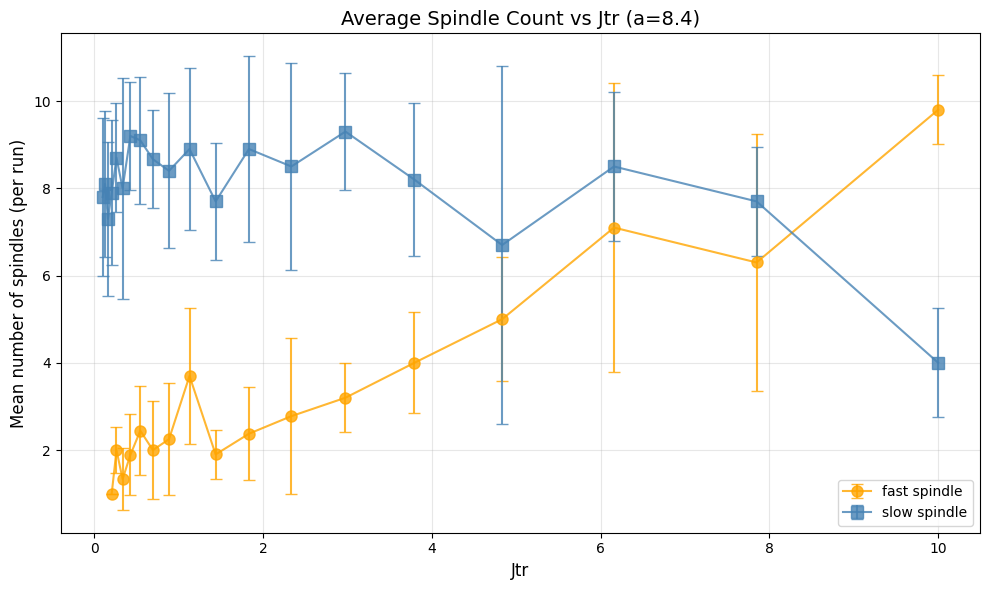

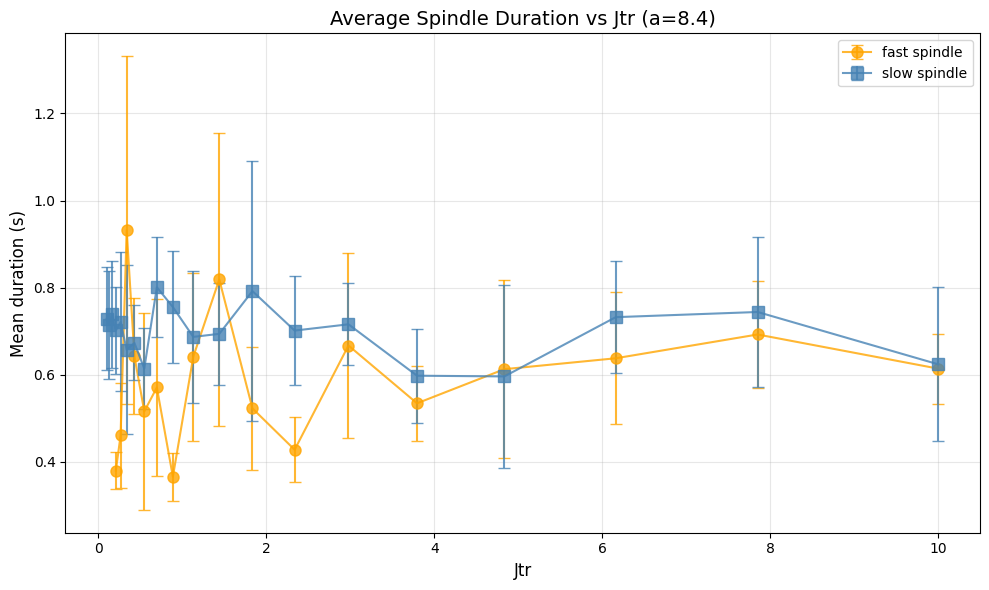

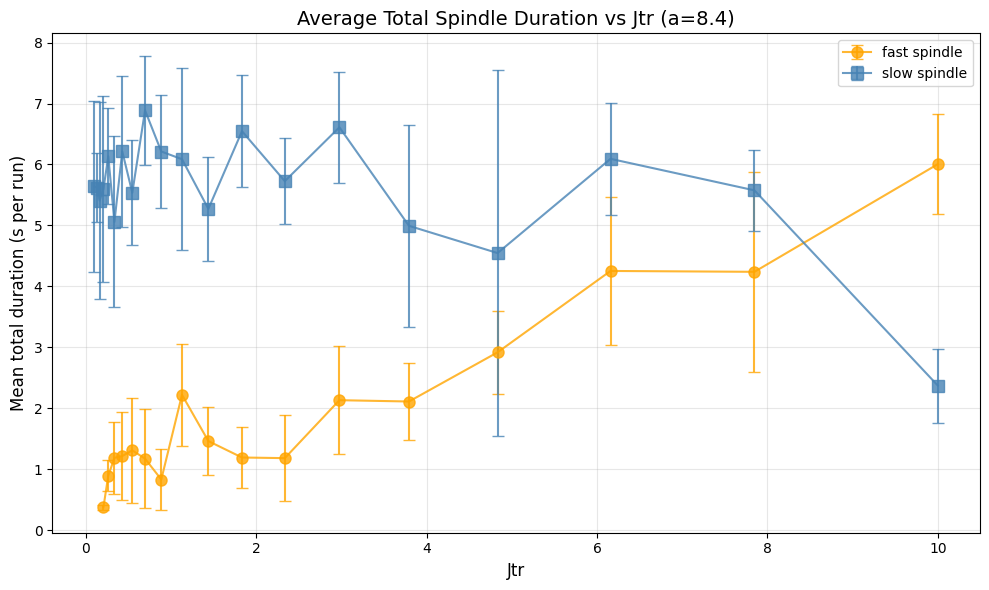

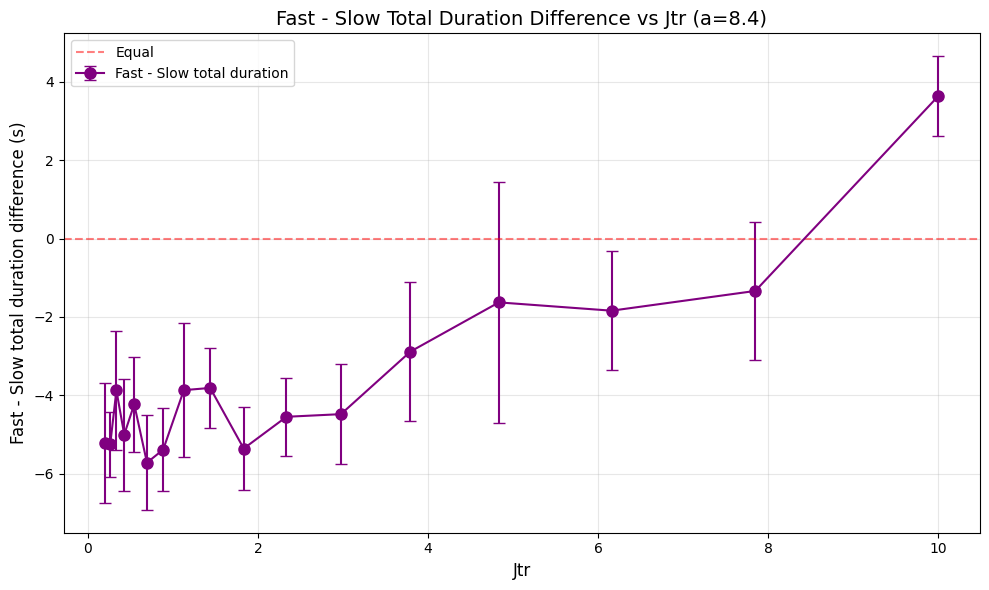


统计检验：每个 Jtr 下快慢纺锤波总时长比较
Jtr=0.207: fast_n=2, slow_n=10, fast_mean=0.38s, slow_mean=5.60s, p=0.0303 (显著)
Jtr=0.264: fast_n=8, slow_n=10, fast_mean=0.90s, slow_mean=6.13s, p=0.0000 (显著)
Jtr=0.336: fast_n=9, slow_n=10, fast_mean=1.19s, slow_mean=5.06s, p=0.0004 (显著)
Jtr=0.428: fast_n=9, slow_n=10, fast_mean=1.22s, slow_mean=6.21s, p=0.0003 (显著)
Jtr=0.546: fast_n=9, slow_n=10, fast_mean=1.31s, slow_mean=5.54s, p=0.0003 (显著)
Jtr=0.695: fast_n=9, slow_n=9, fast_mean=1.18s, slow_mean=6.89s, p=0.0004 (显著)
Jtr=0.886: fast_n=8, slow_n=10, fast_mean=0.83s, slow_mean=6.21s, p=0.0000 (显著)
Jtr=1.129: fast_n=10, slow_n=10, fast_mean=2.22s, slow_mean=6.09s, p=0.0006 (显著)
Jtr=1.438: fast_n=10, slow_n=10, fast_mean=1.46s, slow_mean=5.27s, p=0.0002 (显著)
Jtr=1.833: fast_n=8, slow_n=10, fast_mean=1.19s, slow_mean=6.55s, p=0.0000 (显著)
Jtr=2.336: fast_n=9, slow_n=10, fast_mean=1.18s, slow_mean=5.73s, p=0.0003 (显著)
Jtr=2.976: fast_n=10, slow_n=10, fast_mean=2.13s, slow_mean=6.61s, p=0.0002 (显著)
Jtr=3.793: fa

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ========== 1. 读取数据 ==========
CSV_PATH = "data/analysis_data/spindles_a8.4_Jtr_scan.csv"
df = pd.read_csv(CSV_PATH)

print(f"读取 {len(df)} 个纺锤波")

# ========== 2. 查看 Jtr 的取值范围 ==========
Jtr_values = sorted(df['Jtr'].unique())
print(f"\nJtr 值: {Jtr_values}")

# ========== 3. 按 Jtr, seed, type 分组统计每个 seed 的总时长 ==========
seed_total_duration = df.groupby(['Jtr', 'seed', 'type'])['duration'].sum().reset_index(name='total_duration')

# 再按 Jtr 和 type 分组，计算所有 seed 的平均总时长和标准差
total_duration_stats = seed_total_duration.groupby(['Jtr', 'type']).agg(
    mean_total_duration=('total_duration', 'mean'),
    std_total_duration=('total_duration', 'std'),
    n_seeds=('total_duration', 'count')
).reset_index()

print("\n" + "="*60)
print("平均总时长统计（每个 seed 先统计总时长，再对 seed 平均）")
print("="*60)

for Jtr_val in Jtr_values:
    print(f"\n--- Jtr = {Jtr_val:.3f} ---")
    for spindle_type in ['fast', 'slow']:
        subset = total_duration_stats[(total_duration_stats['Jtr'] == Jtr_val) & 
                                      (total_duration_stats['type'] == spindle_type)]
        if len(subset) > 0:
            row = subset.iloc[0]
            print(f"  {spindle_type}: mean_total_duration={row['mean_total_duration']:.3f}±{row['std_total_duration']:.3f}s (n_seeds={row['n_seeds']:.0f})")

# ========== 4. 图1：平均纺锤波个数（折线图，带误差棒）==========
# 先按 Jtr, seed, type 分组统计每个 seed 的个数
seed_counts = df.groupby(['Jtr', 'seed', 'type']).size().reset_index(name='count')
count_stats = seed_counts.groupby(['Jtr', 'type']).agg(
    mean_count=('count', 'mean'),
    std_count=('count', 'std'),
    n_seeds=('count', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = count_stats[count_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jtr')
        ax.errorbar(subset_sorted['Jtr'], subset_sorted['mean_count'], 
                    yerr=subset_sorted['std_count'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jtr', fontsize=12)
ax.set_ylabel('Mean number of spindles (per run)', fontsize=12)
ax.set_title('Average Spindle Count vs Jtr (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 5. 图2：平均持续时长（折线图，带误差棒）==========
# 先按 Jtr, seed, type 分组统计每个 seed 的平均时长
seed_durations = df.groupby(['Jtr', 'seed', 'type'])['duration'].mean().reset_index(name='mean_duration')
duration_stats = seed_durations.groupby(['Jtr', 'type']).agg(
    mean_duration=('mean_duration', 'mean'),
    std_duration=('mean_duration', 'std'),
    n_seeds=('mean_duration', 'count')
).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = duration_stats[duration_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jtr')
        ax.errorbar(subset_sorted['Jtr'], subset_sorted['mean_duration'], 
                    yerr=subset_sorted['std_duration'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jtr', fontsize=12)
ax.set_ylabel('Mean duration (s)', fontsize=12)
ax.set_title('Average Spindle Duration vs Jtr (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 6. 图3：总时长（折线图，带误差棒）==========
fig, ax = plt.subplots(figsize=(10, 6))

for spindle_type, color, marker in [('fast', 'orange', 'o'), ('slow', 'steelblue', 's')]:
    subset = total_duration_stats[total_duration_stats['type'] == spindle_type]
    if len(subset) > 0:
        subset_sorted = subset.sort_values('Jtr')
        ax.errorbar(subset_sorted['Jtr'], subset_sorted['mean_total_duration'], 
                    yerr=subset_sorted['std_total_duration'],
                    fmt=f'{marker}-', color=color, capsize=4,
                    label=f'{spindle_type} spindle', 
                    markersize=8, linewidth=1.5, alpha=0.8)

ax.set_xlabel('Jtr', fontsize=12)
ax.set_ylabel('Mean total duration (s per run)', fontsize=12)
ax.set_title('Average Total Spindle Duration vs Jtr (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 7. 图4：快慢差值（总时长差值）==========
# 合并快慢数据计算差值
fast_total = total_duration_stats[total_duration_stats['type'] == 'fast'][['Jtr', 'mean_total_duration', 'std_total_duration']].rename(
    columns={'mean_total_duration': 'fast_mean', 'std_total_duration': 'fast_std'})
slow_total = total_duration_stats[total_duration_stats['type'] == 'slow'][['Jtr', 'mean_total_duration', 'std_total_duration']].rename(
    columns={'mean_total_duration': 'slow_mean', 'std_total_duration': 'slow_std'})

diff_stats = pd.merge(fast_total, slow_total, on='Jtr', how='outer')
diff_stats = diff_stats.dropna()
diff_stats['diff'] = diff_stats['fast_mean'] - diff_stats['slow_mean']
diff_stats['diff_std'] = np.sqrt(diff_stats['fast_std']**2 + diff_stats['slow_std']**2)

fig, ax = plt.subplots(figsize=(10, 6))

ax.errorbar(diff_stats['Jtr'], diff_stats['diff'], 
            yerr=diff_stats['diff_std'],
            fmt='o-', color='purple', capsize=4,
            label='Fast - Slow total duration', markersize=8, linewidth=1.5)
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Equal')
ax.set_xlabel('Jtr', fontsize=12)
ax.set_ylabel('Fast - Slow total duration difference (s)', fontsize=12)
ax.set_title('Fast - Slow Total Duration Difference vs Jtr (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 8. 统计检验 ==========
print("\n" + "="*60)
print("统计检验：每个 Jtr 下快慢纺锤波总时长比较")
print("="*60)

for Jtr_val in Jtr_values:
    fast_total_seed = seed_total_duration[(seed_total_duration['Jtr'] == Jtr_val) & 
                                          (seed_total_duration['type'] == 'fast')]['total_duration'].values
    slow_total_seed = seed_total_duration[(seed_total_duration['Jtr'] == Jtr_val) & 
                                          (seed_total_duration['type'] == 'slow')]['total_duration'].values
    
    if len(fast_total_seed) > 0 and len(slow_total_seed) > 0:
        u, p = mannwhitneyu(fast_total_seed, slow_total_seed)
        print(f"Jtr={Jtr_val:.3f}: fast_n={len(fast_total_seed)}, slow_n={len(slow_total_seed)}, "
              f"fast_mean={np.mean(fast_total_seed):.2f}s, slow_mean={np.mean(slow_total_seed):.2f}s, "
              f"p={p:.4f} ({'显著' if p < 0.05 else '不显著'})")

# ========== 9. 找最佳参数 ==========
print("\n" + "="*60)
print("最佳参数总结（基于平均总时长）")
print("="*60)

# 快纺锤波总时长最多的 Jtr
fast_max_idx = total_duration_stats[total_duration_stats['type'] == 'fast']['mean_total_duration'].idxmax()
best_Jtr_fast = total_duration_stats.loc[fast_max_idx, 'Jtr']
best_fast = total_duration_stats.loc[fast_max_idx, 'mean_total_duration']

# 慢纺锤波总时长最多的 Jtr
slow_max_idx = total_duration_stats[total_duration_stats['type'] == 'slow']['mean_total_duration'].idxmax()
best_Jtr_slow = total_duration_stats.loc[slow_max_idx, 'Jtr']
best_slow = total_duration_stats.loc[slow_max_idx, 'mean_total_duration']

print(f"快纺锤波总时长最多: Jtr={best_Jtr_fast:.3f}, total={best_fast:.2f}s")
print(f"慢纺锤波总时长最多: Jtr={best_Jtr_slow:.3f}, total={best_slow:.2f}s")

#### 追加：不同Jtr下的频谱

Jtr 值: [0.1, 0.1274, 0.1624, 0.2069, 0.2637, 0.336, 0.4281, 0.5456, 0.6952, 0.8859, 1.1288, 1.4384, 1.833, 2.3357, 2.9764, 3.7927, 4.8329, 6.1585, 7.8476, 10.0]
找到 200 个文件


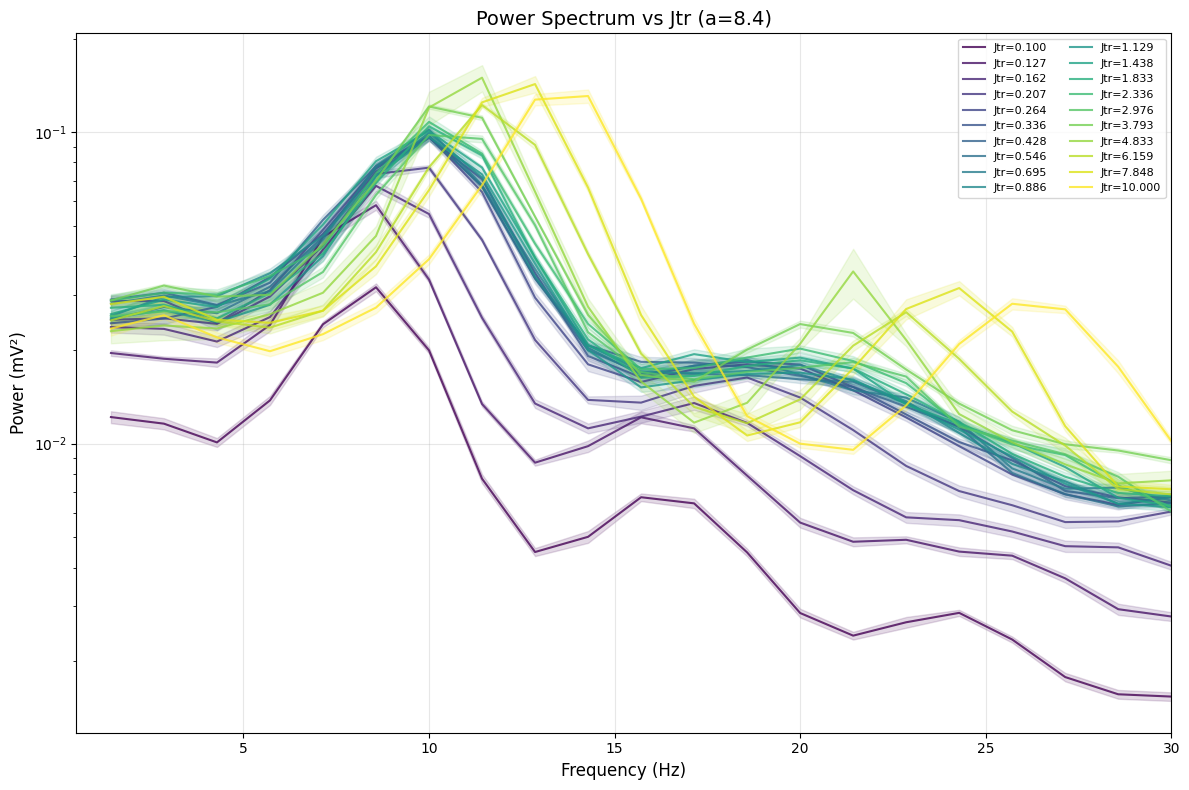

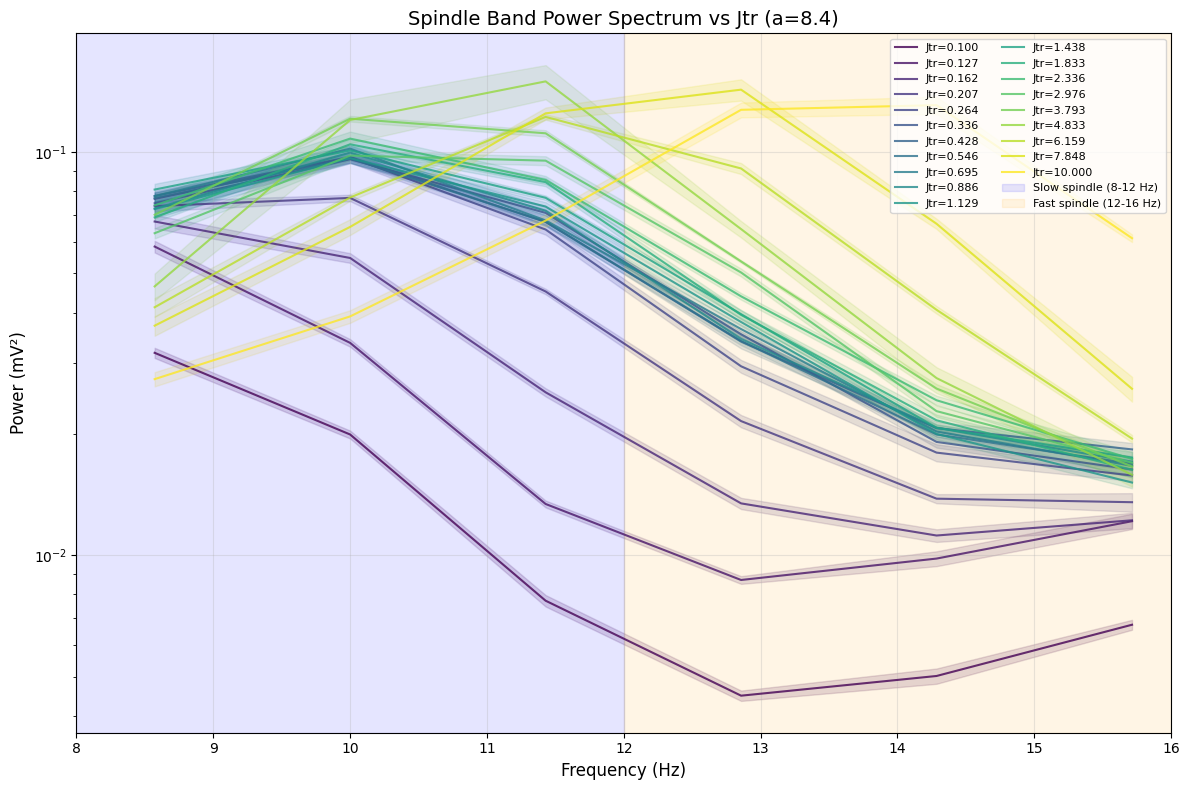

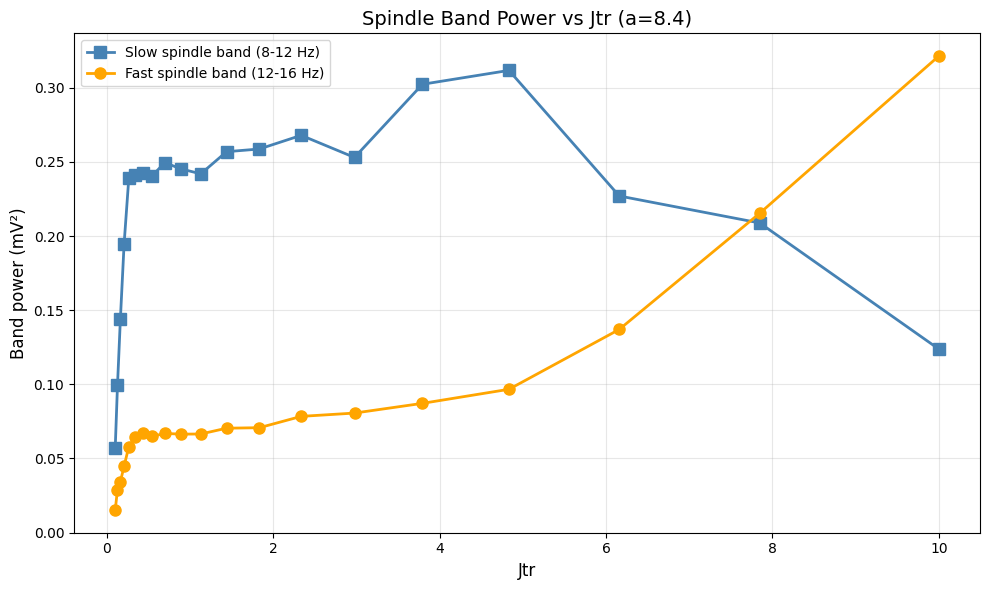

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os
import matplotlib.ticker as ticker

# ========== 1. 参数设置 ==========
sf = 10000  # 采样率
DATA_DIR = "data/raw_data_a8.4_Jtr_scan"  # 存放 npy 文件的目录
CSV_PATH = "data/analysis_data/spindles_a8.4_Jtr_scan.csv"

# PSD 参数
nperseg = int(sf * 0.7)  # 0.7 秒窗口
freq_range = (0.5, 30)   # 显示频率范围

# ========== 2. 读取 CSV 获取所有 Jtr 值 ==========
df = pd.read_csv(CSV_PATH)
Jtr_values = sorted(df['Jtr'].unique())
print(f"Jtr 值: {Jtr_values}")

# ========== 3. 建立文件映射：每个 (Jtr, seed) 对应的文件路径 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for f in file_list:
    filename = os.path.basename(f)
    parts = filename.replace(".npy", "").split("_")
    # 根据你的文件名格式: a_8.4000_Jtr_-0.5000_..._seed_1
    Jtr_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jtr_val, seed)] = f

print(f"找到 {len(file_map)} 个文件")

# ========== 4. 对每个 Jtr 计算平均 PSD ==========
# 统一频率轴
freqs = None
psd_by_Jtr = {}  # {Jtr: {'fast': [psd_list], 'slow': [psd_list]}}
spindle_info_by_Jtr = {}  # 存储每个 Jtr 下每个 seed 的纺锤波信息

for Jtr_val in Jtr_values:
    # 找该 Jtr 下所有的 seed
    seeds = df[df['Jtr'] == Jtr_val]['seed'].unique()
    psd_list_fast = []
    psd_list_slow = []
    
    for seed in seeds:
        key = (Jtr_val, seed)
        if key not in file_map:
            continue
        
        # 加载数据
        data = np.load(file_map[key], allow_pickle=True).item()
        V_t = data["V_t"]
        
        # 计算 PSD
        f, Pxx = signal.welch(V_t, sf, nperseg=nperseg, scaling='spectrum')
        
        if freqs is None:
            freqs = f
        
        # 找该 seed 下快慢纺锤波的持续时间（用于后续按需分析）
        # 这里我们直接保存 PSD
        psd_list_fast.append(Pxx)
        psd_list_slow.append(Pxx)  # 暂存，用于分组
    
    # 对同一 Jtr 下的所有 PSD 求平均和标准差
    if len(psd_list_fast) > 0:
        psd_array_fast = np.array(psd_list_fast)
        psd_by_Jtr[Jtr_val] = {
            'fast': {
                'mean': np.mean(psd_array_fast, axis=0),
                'std': np.std(psd_array_fast, axis=0),
                'n': len(psd_array_fast)
            }
        }
        
        # 慢纺锤波也可以用同样的数据（因为 PSD 是所有频段的，不区分纺锤波类型）
        # 但如果你想要分别分析快慢纺锤波期间的 PSD，需要根据纺锤波事件截取信号
        # 这里我们先用全信号 PSD
        psd_by_Jtr[Jtr_val]['slow'] = {
            'mean': np.mean(psd_array_fast, axis=0),
            'std': np.std(psd_array_fast, axis=0),
            'n': len(psd_array_fast)
        }

# ========== 5. 画图：所有 Jtr 的 PSD 叠加 ==========
fig, ax = plt.subplots(figsize=(12, 8))

# 颜色映射
colors = plt.cm.viridis(np.linspace(0, 1, len(Jtr_values)))

for i, Jtr_val in enumerate(Jtr_values):
    if Jtr_val not in psd_by_Jtr:
        continue
    data = psd_by_Jtr[Jtr_val]['fast']
    mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.5, 
                label=f'Jtr={Jtr_val:.3f}', alpha=0.8)
    # 添加误差带（±SEM）
    sem = data['std'] / np.sqrt(data['n'])
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Power Spectrum vs Jtr (a=8.4)', fontsize=14)
ax.set_xlim(freq_range[0], freq_range[1])
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# 设置 Y 轴刻度
ax.yaxis.set_major_locator(ticker.LogLocator(numticks=5))
plt.tight_layout()
plt.show()

# ========== 6. 画图：纺锤波频段放大（8–16 Hz）==========
fig, ax = plt.subplots(figsize=(12, 8))

for i, Jtr_val in enumerate(Jtr_values):
    if Jtr_val not in psd_by_Jtr:
        continue
    data = psd_by_Jtr[Jtr_val]['fast']
    mask = (freqs >= 8) & (freqs <= 16)
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.5, 
                label=f'Jtr={Jtr_val:.3f}', alpha=0.8)
    
    sem = data['std'] / np.sqrt(data['n'])
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

# 标记快慢纺锤波频段
ax.axvspan(8, 12, alpha=0.1, color='blue', label='Slow spindle (8-12 Hz)')
ax.axvspan(12, 16, alpha=0.1, color='orange', label='Fast spindle (12-16 Hz)')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power Spectrum vs Jtr (a=8.4)', fontsize=14)
ax.set_xlim(8, 16)
ax.legend(loc='upper right', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 7. 提取纺锤波频段功率并画图 ==========
# 计算每个 Jtr 下纺锤波频段的平均功率
band_power_stats = []

for Jtr_val in Jtr_values:
    if Jtr_val not in psd_by_Jtr:
        continue
    
    # 慢纺锤波频段 (8-12 Hz)
    slow_mask = (freqs >= 8) & (freqs <= 12)
    slow_power = np.trapz(psd_by_Jtr[Jtr_val]['fast']['mean'][slow_mask], freqs[slow_mask])
    
    # 快纺锤波频段 (12-16 Hz)
    fast_mask = (freqs >= 12) & (freqs <= 16)
    fast_power = np.trapz(psd_by_Jtr[Jtr_val]['fast']['mean'][fast_mask], freqs[fast_mask])
    
    band_power_stats.append({
        'Jtr': Jtr_val,
        'slow_band_power': slow_power,
        'fast_band_power': fast_power,
    })

band_power_df = pd.DataFrame(band_power_stats)

# 画图：纺锤波频段功率随 Jtr 变化
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(band_power_df['Jtr'], band_power_df['slow_band_power'], 
        's-', color='steelblue', linewidth=2, markersize=8, label='Slow spindle band (8-12 Hz)')
ax.plot(band_power_df['Jtr'], band_power_df['fast_band_power'], 
        'o-', color='orange', linewidth=2, markersize=8, label='Fast spindle band (12-16 Hz)')

ax.set_xlabel('Jtr', fontsize=12)
ax.set_ylabel('Band power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power vs Jtr (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

所有 Jtr 值: [0.1, 0.1274, 0.1624, 0.2069, 0.2637, 0.336, 0.4281, 0.5456, 0.6952, 0.8859, 1.1288, 1.4384, 1.833, 2.3357, 2.9764, 3.7927, 4.8329, 6.1585, 7.8476, 10.0]
共 20 个

选取的代表性 Jtr 值: [0.1, 1.4384, 2.9764, 4.8329, 6.1585, 7.8476, 10.0]
共 7 个
找到 200 个文件


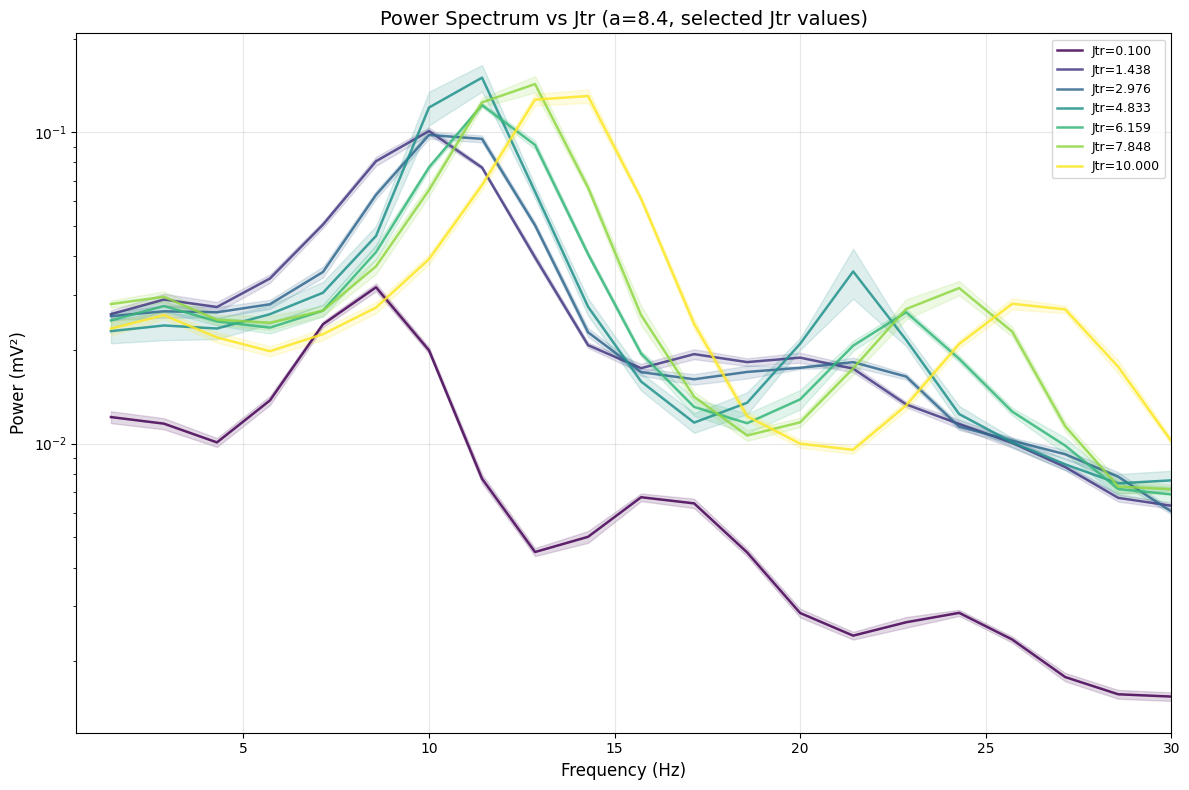

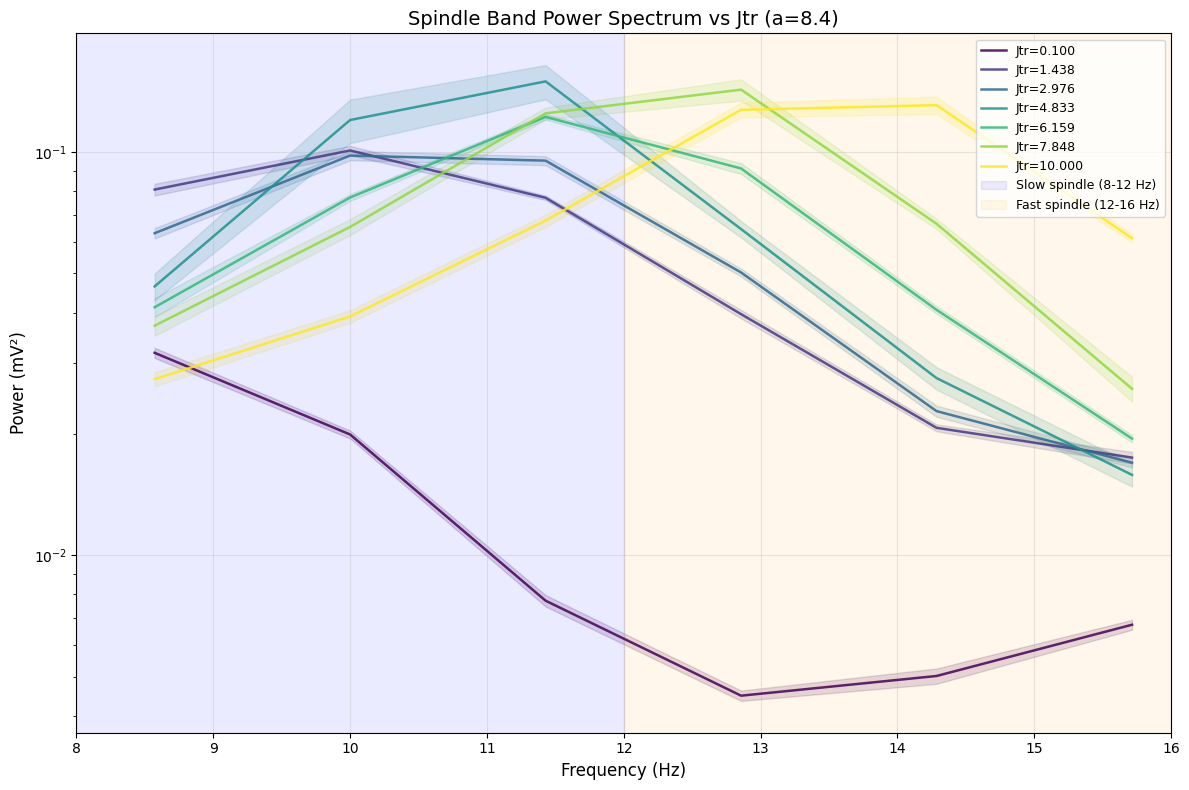

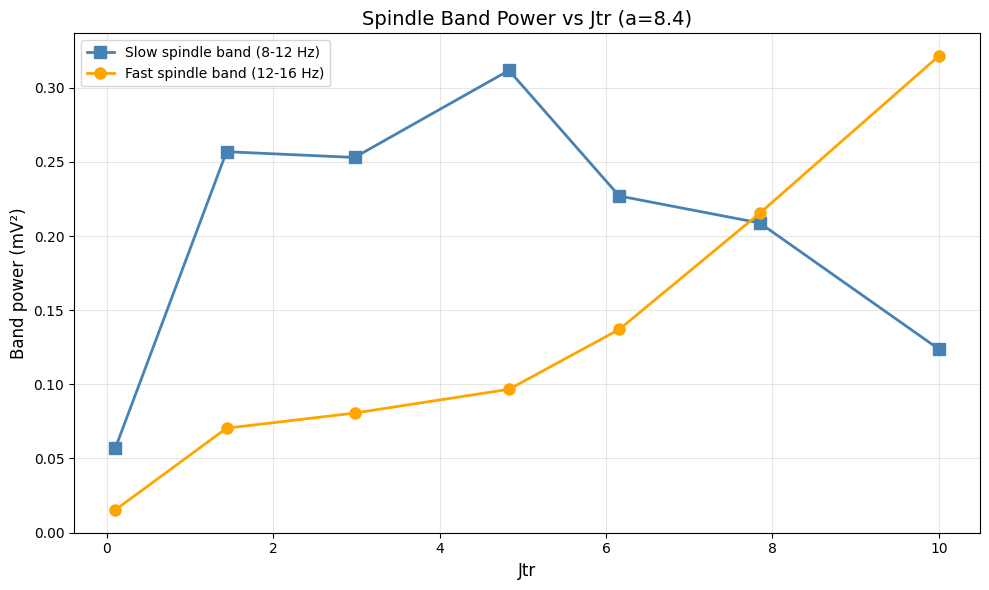


纺锤波频段总功率（选中的 Jtr 值）
Jtr=0.100: slow=0.0567 mV², fast=0.0152 mV²
Jtr=1.438: slow=0.2569 mV², fast=0.0704 mV²
Jtr=2.976: slow=0.2530 mV², fast=0.0806 mV²
Jtr=4.833: slow=0.3118 mV², fast=0.0966 mV²
Jtr=6.159: slow=0.2270 mV², fast=0.1370 mV²
Jtr=7.848: slow=0.2088 mV², fast=0.2154 mV²
Jtr=10.000: slow=0.1238 mV², fast=0.3215 mV²


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal
import glob
import os
import matplotlib.ticker as ticker

# ========== 1. 参数设置 ==========
sf = 10000
DATA_DIR = "data/raw_data_a8.4_Jtr_scan"
CSV_PATH = "data/analysis_data/spindles_a8.4_Jtr_scan.csv"

nperseg = int(sf * 0.7)
freq_range = (0.5, 30)

# ========== 2. 读取 CSV 获取所有 Jtr 值 ==========
df = pd.read_csv(CSV_PATH)
all_Jtr_values = sorted(df['Jtr'].unique())
print(f"所有 Jtr 值: {all_Jtr_values}")
print(f"共 {len(all_Jtr_values)} 个")

# ========== 3. 选取代表性的 Jtr 值 ==========
# 方案1：均匀选取 8 个值（覆盖范围）
Jtr_values = np.linspace(all_Jtr_values[0], all_Jtr_values[-1], 8).tolist()
# 四舍五入到 3 位小数，匹配实际值
Jtr_values = [round(v, 3) for v in Jtr_values]
# 找实际数据中最近的值
Jtr_values = sorted(set([min(all_Jtr_values, key=lambda x: abs(x - v)) for v in Jtr_values]))

# 方案2：手动指定（根据你的关注点）
# Jtr_values = [-1.5, -1.2, -0.9, -0.6, -0.3, -0.5, -0.7, -1.0]

print(f"\n选取的代表性 Jtr 值: {Jtr_values}")
print(f"共 {len(Jtr_values)} 个")

# ========== 4. 建立文件映射 ==========
file_list = glob.glob(os.path.join(DATA_DIR, "*.npy"))
file_map = {}
for f in file_list:
    filename = os.path.basename(f)
    parts = filename.replace(".npy", "").split("_")
    Jtr_val = float(parts[3])
    seed = int(parts[9])
    file_map[(Jtr_val, seed)] = f

print(f"找到 {len(file_map)} 个文件")

# ========== 5. 对每个 Jtr 计算平均 PSD ==========
freqs = None
psd_by_Jtr = {}

for Jtr_val in Jtr_values:
    # 只处理选中的 Jtr 值
    seeds = df[df['Jtr'] == Jtr_val]['seed'].unique()
    psd_list = []
    
    for seed in seeds:
        key = (Jtr_val, seed)
        if key not in file_map:
            continue
        
        data = np.load(file_map[key], allow_pickle=True).item()
        V_t = data["V_t"]
        
        f, Pxx = signal.welch(V_t, sf, nperseg=nperseg, scaling='spectrum')
        
        if freqs is None:
            freqs = f
        
        psd_list.append(Pxx)
    
    if len(psd_list) > 0:
        psd_array = np.array(psd_list)
        psd_by_Jtr[Jtr_val] = {
            'mean': np.mean(psd_array, axis=0),
            'std': np.std(psd_array, axis=0),
            'n': len(psd_array)
        }

# ========== 6. 画图：全频段 ==========
fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.viridis(np.linspace(0, 1, len(Jtr_values)))

for i, Jtr_val in enumerate(Jtr_values):
    if Jtr_val not in psd_by_Jtr:
        continue
    data = psd_by_Jtr[Jtr_val]
    mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
    
    sem = data['std'] / np.sqrt(data['n'])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.8, 
                label=f'Jtr={Jtr_val:.3f}', alpha=0.85)
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Power Spectrum vs Jtr (a=8.4, selected Jtr values)', fontsize=14)
ax.set_xlim(freq_range[0], freq_range[1])
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.yaxis.set_major_locator(ticker.LogLocator(numticks=5))
plt.tight_layout()
plt.show()

# ========== 7. 画图：纺锤波频段放大（8–16 Hz）==========
fig, ax = plt.subplots(figsize=(12, 8))

for i, Jtr_val in enumerate(Jtr_values):
    if Jtr_val not in psd_by_Jtr:
        continue
    data = psd_by_Jtr[Jtr_val]
    mask = (freqs >= 8) & (freqs <= 16)
    
    sem = data['std'] / np.sqrt(data['n'])
    
    ax.semilogy(freqs[mask], data['mean'][mask], 
                color=colors[i], linewidth=1.8, 
                label=f'Jtr={Jtr_val:.3f}', alpha=0.85)
    ax.fill_between(freqs[mask], 
                    data['mean'][mask] - sem[mask], 
                    data['mean'][mask] + sem[mask], 
                    color=colors[i], alpha=0.15)

ax.axvspan(8, 12, alpha=0.08, color='blue', label='Slow spindle (8-12 Hz)')
ax.axvspan(12, 16, alpha=0.08, color='orange', label='Fast spindle (12-16 Hz)')

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power Spectrum vs Jtr (a=8.4)', fontsize=14)
ax.set_xlim(8, 16)
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 8. 频段总功率随 Jtr 变化 ==========
band_power_stats = []

for Jtr_val in Jtr_values:
    if Jtr_val not in psd_by_Jtr:
        continue
    
    slow_mask = (freqs >= 8) & (freqs <= 12)
    slow_power = np.trapz(psd_by_Jtr[Jtr_val]['mean'][slow_mask], freqs[slow_mask])
    
    fast_mask = (freqs >= 12) & (freqs <= 16)
    fast_power = np.trapz(psd_by_Jtr[Jtr_val]['mean'][fast_mask], freqs[fast_mask])
    
    band_power_stats.append({
        'Jtr': Jtr_val,
        'slow_band_power': slow_power,
        'fast_band_power': fast_power,
    })

band_power_df = pd.DataFrame(band_power_stats)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(band_power_df['Jtr'], band_power_df['slow_band_power'], 
        's-', color='steelblue', linewidth=2, markersize=8, label='Slow spindle band (8-12 Hz)')
ax.plot(band_power_df['Jtr'], band_power_df['fast_band_power'], 
        'o-', color='orange', linewidth=2, markersize=8, label='Fast spindle band (12-16 Hz)')

ax.set_xlabel('Jtr', fontsize=12)
ax.set_ylabel('Band power (mV²)', fontsize=12)
ax.set_title('Spindle Band Power vs Jtr (a=8.4)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ========== 9. 打印统计 ==========
print("\n" + "="*60)
print("纺锤波频段总功率（选中的 Jtr 值）")
print("="*60)

for _, row in band_power_df.iterrows():
    print(f"Jtr={row['Jtr']:.3f}: slow={row['slow_band_power']:.4f} mV², fast={row['fast_band_power']:.4f} mV²")

In [7]:
alkhg;sldg

NameError: name 'alkhg' is not defined